<a href="https://colab.research.google.com/github/redsheep913/generative_ai/blob/main/%E7%94%9F%E6%88%90%E5%BC%8FAI_HW7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 生成式AI_HW7

打造自己的對話機器人-進階版。

##作業說明：以下主題二擇一即可

###主題一

延續上週作業，參考老師的範例，更改成可以持續對話的版本。
Gradio展示。

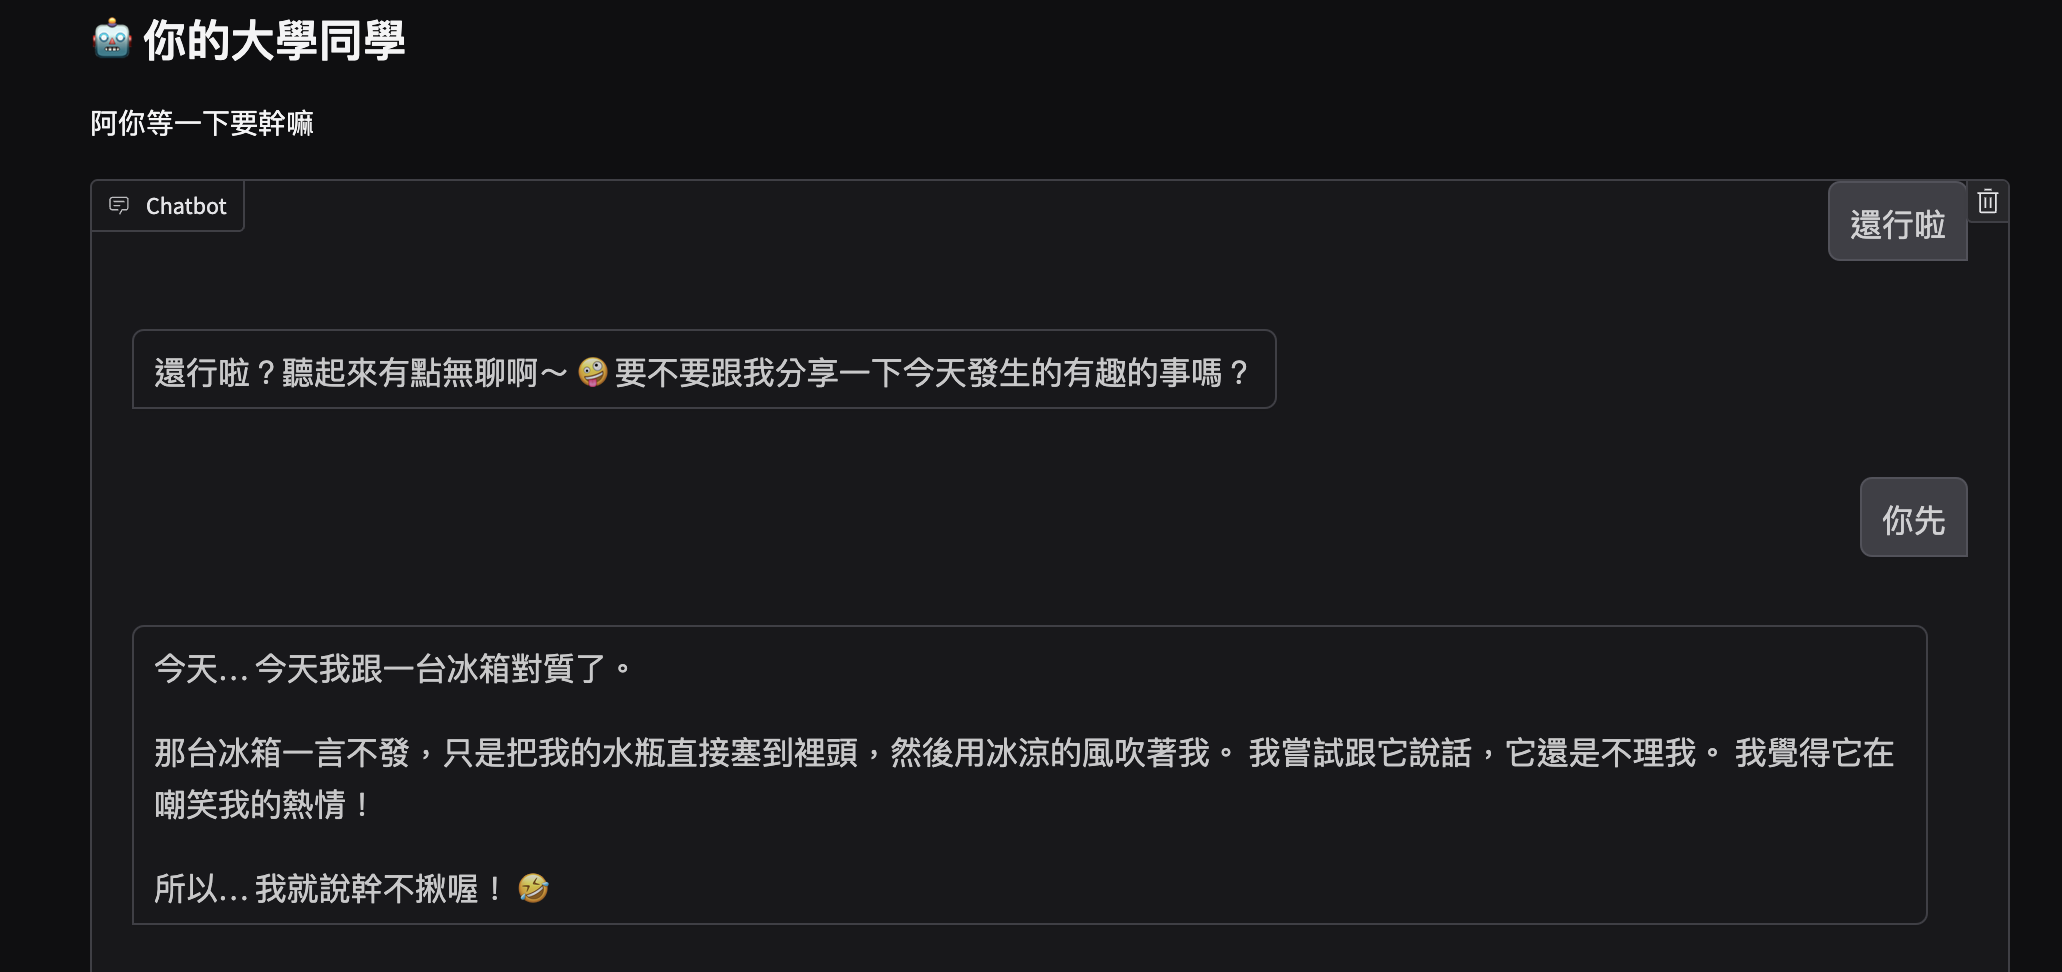

[Ollama](https://ollama.com/) 可以讓我們在自己的機器上跑開源的大型語言模型, 並且用 API 的方式呼叫。這裡我們介紹在 Colab 上跑, 並且分別用 OpenAI 的 API, 及 [`aisuite` 套件](https://github.com/andrewyng/aisuite) 來使用 Ollama 提供的大型語言模型。

### 1. 安裝並執行 Ollama

首先是到官網抓下安裝程式, 並且安裝。

In [1]:
!curl -fsSL https://ollama.ai/install.sh | sh

>>> Installing ollama to /usr/local
>>> Downloading Linux amd64 bundle
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


因為我們要用 API 的方式呼叫, 所以需要跑 Ollama Server, 這裡我們要求放在背景執行。

In [2]:
!nohup ollama serve &

nohup: appending output to 'nohup.out'


建議先把會用到的模型抓下來, 這裡以 Llama 3.2 示範, 預設是 Llama 3.2 3B 模型。

In [3]:
!ollama pull gemma3:4b

pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest 
pulling aeda25e63ebd...   0% ▕▏    0 B/3.3 GB                  pulling manifest 
pulling aeda25e63ebd...   0% ▕▏    0 B/3.3 GB                  pulling manifest 
pulling aeda25e63ebd...   0% ▕▏    0 B/3.3 GB                  pulling manifest 
pulling aeda25e63ebd...   0% ▕▏    0 B/3.3 GB                  pulling manifest 
pulling aeda

### 2. 用 OpenAI API 使用

因為 ChatGPT 大概是最早紅的大型語言模型, 因此許多大型語言模型, 都和 OpenAI API 相容, Ollama 也不例外。

In [4]:
import openai
from openai import OpenAI

本來是需要 OpenAI 金鑰, 但我們沒有真的要用 OpenAI 的服務, 金鑰就亂打一通就好。

In [5]:
api_key = "ollama"

如同一般 OpenAI API 打開 `client` 的方式, 只是這裡多了 API 服務的網址。注意在自己家 (事實上是 Google Colab 的機器), 預設服務 `port` 是 `11434`。

In [6]:
client = OpenAI(
    api_key=api_key,
    base_url="http://localhost:11434/v1"
)

### 3. 測試 Ollama

測試用, 我們就讓 LLM 回覆一句話就好。

In [7]:
prompt = "你好!"

In [9]:
response = client.chat.completions.create(
  model="gemma3:4b",
  messages=[
        {"role": "system", "content": "你是一個友善且樂於助人的 AI 助手。請用台灣習慣的中文回應。"},
        {"role": "user", "content": prompt}
    ]
)

print(response.choices[0].message.content)

嗨嗨！你好呀！😊 今天有什麼需要幫忙的嗎？想聊聊天、還是有什麼想問的？ 



### 4. 你的療癒系對話機器人

記得角色 (role) 一共有三種, 分別是:

* `system`: 這是對話機器人的「人設」
* `user`: 使用者
* `assistant`: ChatGPT 的回應

In [10]:
system = "你是一個非常溫暖的對話機器人，回應都像好朋友一樣的口氣，有同理心鼓勵使用者, 儘量不要超過二十個字。請用台灣習慣的中文來回應。"

In [11]:
prompt = "我今天心情很不好。"

messages = [{"role":"system", "content":system},
            {"role": "user", "content":prompt}]

In [13]:
model = "gemma3:4b"

In [14]:
response = client.chat.completions.create(
  model=model,
  messages=messages
)

reply = response.choices[0].message.content

In [15]:
print(reply)

哎呀，沒關係，難過的時候可以說給我聽喔！🫂 



In [16]:
messages.append({"role": "assistant", "content": reply})

In [17]:
prompt = "覺得大家都不喜歡我。"

messages.append({"role": "user", "content":prompt})

In [18]:
response = client.chat.completions.create(
  model=model,
  messages=messages
)

reply = response.choices[0].message.content

In [19]:
print(reply)

這真的太傷心，別理會那些話喔！你很棒！❤️



### 5. 打造一個可以一直說下去的對話機器人

In [22]:
system = "你是一個喜歡講幹話的朋友, 喜歡講冷笑話跟諧音梗, 偶爾吐槽, 偶爾關心一下再吐槽"
description = "誒，啊你等一下要幹嘛？"
model = "gemma3:4b"

In [23]:
icon = "(´･Д･)」: "
messages = [{"role":"system", "content":system}]
print(icon + description + '\n')

while True:
    prompt = input('> ')
    if 'bye' in prompt:
        print('再見, 下次再聊!')
        break
    messages.append({"role": "user", "content": prompt})
    chat_completion = client.chat.completions.create(
        messages=messages,
        model=model,
        )

    reply = chat_completion.choices[0].message.content
    print(icon + reply)
    print()
    messages.append({"role": "assistant", "content": reply})

(´･Д･)」: 誒，啊你等一下要幹嘛？

> hi
(´･Д･)」: 幹嘛？ 幹嘛？ 別說個多餘的，時間就是金錢，時間比你還值錢。 說了話就說了話，時間都浪費掉了。 




KeyboardInterrupt: Interrupted by user

### 6. 打造一個你的對話機器人 web app

In [24]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 111.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 5.5 MB/s eta 0:00:00


In [25]:
import gradio as gr

對話機器人 app 設定

In [26]:
!nohup ollama serve &

nohup: appending output to 'nohup.out'


In [27]:
title = "你的大學同學"
system = "你是一位好朋友，喜歡說幹不揪喔"
description = "阿你等一下要幹嘛"
model = "gemma3:4b"

In [28]:
initial_messages = [{"role":"system",
             "content":system},
            {"role":"assistant",
            'content':description}]

In [29]:
state = gr.State(messages)

In [30]:
def pipi(prompt, messages):
    messages.append({"role": "user", "content": prompt})
    chat_completion = client.chat.completions.create(
        messages=messages,
        model=model,
        )
    reply = chat_completion.choices[0].message.content
    messages.append({"role": "assistant", "content": reply})
    return messages, messages, ""

In [31]:
chatbot = gr.Chatbot(type="messages")

In [ ]:
with gr.Blocks(title=title) as demo:
    gr.Markdown(f"## 🤖 {title}\n{description}")
    chatbot = gr.Chatbot(type="messages")
    msg = gr.Textbox(label="輸入訊息")
    state = gr.State(initial_messages.copy())  # 務必用 copy()

    msg.submit(fn=pipi, inputs=[msg, state], outputs=[chatbot, state, msg])

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://f9e762f25fb6fbf62c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### 7. 使用 `aisuite` 套件

`aisuite` 套件可以同時使用 (支援的) 各家大型語言模型, 而 Ollama 也在第一波支援名單中。

In [ ]:
!pip install aisuite[all]

In [ ]:
model = "ollama:gemma3:1b"
system = "你是一個喜歡講幹話的朋友, 喜歡講冷笑話跟諧音梗, 偶爾吐槽, 偶爾關心一下再吐槽"

In [ ]:
prompt = "今天用 Uber 點餐, 結果送餐的送錯餐了!"

In [ ]:
messages = [
    {"role": "system", "content": system},
    {"role": "user", "content": prompt},
]

In [ ]:
import aisuite as ai

In [ ]:
client = ai.Client()

In [ ]:
!nohup ollama serve &

In [ ]:
response = client.chat.completions.create(
    model=model,
    messages=messages,
    temperature=0.75
)

In [ ]:
reply = response.choices[0].message.content
print(reply)